In [178]:
import pandas as pd
import matplotlib.pyplot as plt 
import sklearn as sk 


In [179]:
df = pd.read_csv(r"D:\Repos\ML-Practice\ML\Uber\cleaned_uber.csv")

In [180]:
df.head(15)

,fare_amount,passenger_count,month,day,weekday,year,hour,distance
0,7.5,1,5,7,3,2015,19,1.683323
1,7.7,1,7,17,4,2009,20,2.457590
2,12.9,1,8,24,0,2009,21,5.036377
3,5.3,3,6,26,4,2009,8,1.661683
4,16.0,5,8,28,3,2014,17,4.475450
5,4.9,1,2,12,5,2011,2,0.000000
6,24.5,5,10,12,6,2014,7,11.731015
7,2.5,1,12,11,1,2012,13,0.000000
8,9.7,1,2,17,4,2012,9,2.332711
9,12.5,1,3,29,3,2012,19,4.889417


In [181]:
Q1 = df['fare_amount'].quantile(0.30)
Q3 = df['fare_amount'].quantile(0.70)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows outside these bounds
df = df[(df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound)]

In [182]:
X = df[["passenger_count",	"month", 	"day",	"weekday",	"hour",	"distance"]]
y = df["fare_amount"]

In [183]:
df.info()

<class 'pandas.DataFrame'>
Index: 177760 entries, 0 to 199998
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      177760 non-null  float64
 1   passenger_count  177760 non-null  int64  
 2   month            177760 non-null  int64  
 3   day              177760 non-null  int64  
 4   weekday          177760 non-null  int64  
 5   year             177760 non-null  int64  
 6   hour             177760 non-null  int64  
 7   distance         177760 non-null  float64
dtypes: float64(2), int64(6)
memory usage: 12.2 MB


In [184]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
    X, y, test_size=0.33, random_state=42)

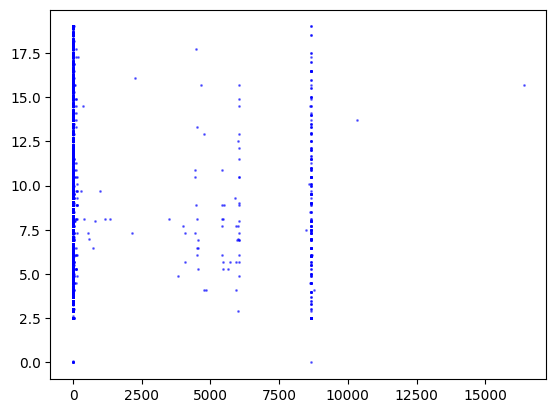

In [185]:
plt.scatter(df['distance'], df['fare_amount'], color='blue', alpha=0.5, s=1)

In [186]:
scaler = sk.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [187]:
model = sk.linear_model.LinearRegression()
model = model.fit(X_train,y_train)
y_train_pred = model.predict(X_train)

In [188]:
sk.metrics.mean_squared_error(y_train, y_train_pred)

13.620606764080565